# GamePredict - Árvore de Decisão para Categoria de Vendas de Jogos

**Disciplina:** Ciência de Dados
**Projeto:** GamePredict — previsão da faixa de vendas de jogos eletrônicos

Este notebook reproduz a lógica do exemplo clássico de árvore de decisão (como o problema do
"restaurante", em que se prevê uma classe categórica — *esperar* ou *não esperar* — a partir de
atributos do cliente) aplicada à base de dados do projeto **GamePredict**.

Diferente da versão original enviada (que usava `DecisionTreeRegressor`, um modelo de **regressão**,
misturado com um trecho de classificação da base Iris que não tinha relação com o projeto), aqui o
modelo é um **`DecisionTreeClassifier`** treinado para prever uma classe: `Baixa`, `Média` ou `Alta`
venda, a partir de:

- `Plataforma`
- `Genero`
- `Ano_Lancamento`
- `Nota_Critica`
- `Nota_Jogadores`

Todas as figuras usam alta resolução (`dpi=150`) e fonte ampliada para garantir legibilidade.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

pd.set_option('display.max_columns', None)

## 1. Carregamento da base de dados

Substitua o caminho abaixo pelo local do seu arquivo, caso esteja rodando fora deste ambiente
(por exemplo, no Google Colab: `/content/base_bruta.xlsx`).

In [2]:
dataset = pd.read_excel("base_bruta.xlsx")
print("Formato da base:", dataset.shape)
dataset.head()

Formato da base: (5000, 9)


/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)


,ID_Jogo,Nome_Jogo,Plataforma,Genero,Ano_Lancamento,Nota_Critica,Nota_Jogadores,Vendas_Milhoes,Origem_Dados
0,1,Arcane Arena Evolution 0001,Xbox Series X/S,Sports,2020,73.0,68.1,12.80,Dados sintéticos
1,2,Frozen Voyage Genesis 0002,PlayStation 4,Shooter,2019,88.2,74.3,6.02,Dados sintéticos
2,3,Solar Horizon Origins 0003,Xbox 360,Sports,2022,75.4,68.0,2.76,Dados sintéticos
3,4,Eternal Outpost Genesis 0004,Xbox One,Sports,2017,54.8,50.8,3.10,Dados sintéticos
4,5,Eternal Horizon Aftermath 0005,Nintendo 3DS,Horror,2018,92.4,95.3,10.73,Dados sintéticos


In [3]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID_Jogo         5000 non-null   int64  
 1   Nome_Jogo       5000 non-null   str    
 2   Plataforma      5000 non-null   str    
 3   Genero          5000 non-null   str    
 4   Ano_Lancamento  5000 non-null   int64  
 5   Nota_Critica    5000 non-null   float64
 6   Nota_Jogadores  5000 non-null   float64
 7   Vendas_Milhoes  5000 non-null   float64
 8   Origem_Dados    5000 non-null   str    
dtypes: float64(3), int64(2), str(4)
memory usage: 351.7 KB


## 2. Criação da variável-alvo (classe)

O objetivo original do projeto era prever `Vendas_Milhoes` (um valor contínuo), o que exigiria um
modelo de **regressão**. Como o requisito agora é um modelo de **classificação** (árvore de
decisão, no estilo do exemplo do restaurante), transformamos as vendas em uma variável categórica
`Categoria_Vendas`, dividindo os jogos em 3 faixas de tamanho igual (terços) com base no volume de
vendas: **Baixa**, **Média** e **Alta**.

In [4]:
dataset['Categoria_Vendas'] = pd.qcut(
    dataset['Vendas_Milhoes'], q=3, labels=['Baixa', 'Média', 'Alta']
)

dataset['Categoria_Vendas'].value_counts()

Categoria_Vendas
Baixa    1669
Alta     1667
Média    1664
Name: count, dtype: int64

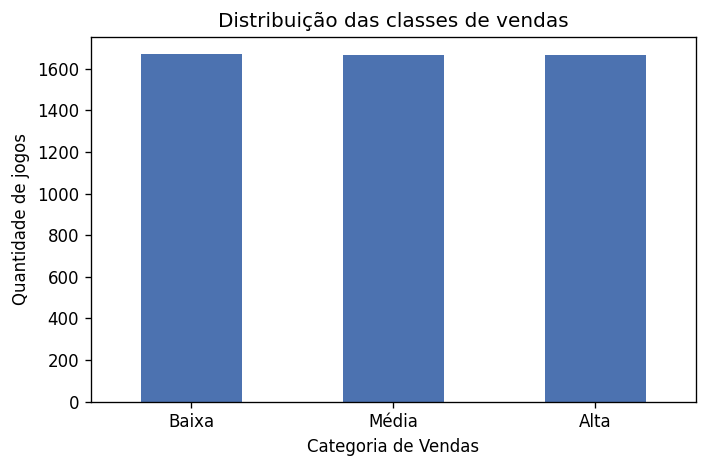

In [5]:
fig, ax = plt.subplots(figsize=(6, 4), dpi=120)
dataset['Categoria_Vendas'].value_counts().sort_index().plot(kind='bar', color='#4C72B0', ax=ax)
ax.set_title('Distribuição das classes de vendas')
ax.set_xlabel('Categoria de Vendas')
ax.set_ylabel('Quantidade de jogos')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 3. Preparação das variáveis (features)

As variáveis categóricas (`Plataforma`, `Genero`) são convertidas em códigos numéricos com
`LabelEncoder`, exatamente como no exemplo do restaurante, em que atributos como "tipo de comida"
ou "tem estacionamento" precisam virar números para o algoritmo da árvore.

In [6]:
le_plataforma = LabelEncoder()
le_genero = LabelEncoder()

dataset['Plataforma_cod'] = le_plataforma.fit_transform(dataset['Plataforma'])
dataset['Genero_cod'] = le_genero.fit_transform(dataset['Genero'])

feature_cols = ['Plataforma_cod', 'Genero_cod', 'Ano_Lancamento', 'Nota_Critica', 'Nota_Jogadores']

X = dataset[feature_cols]
y = dataset['Categoria_Vendas']

X.head()

,Plataforma_cod,Genero_cod,Ano_Lancamento,Nota_Critica,Nota_Jogadores
0,9,10,2020,73.0,68.1
1,4,8,2019,88.2,74.3
2,7,10,2022,75.4,68.0
3,8,10,2017,54.8,50.8
4,0,3,2018,92.4,95.3


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("Treino:", X_train.shape, " Teste:", X_test.shape)

Treino: (3750, 5)  Teste: (1250, 5)


## 4. Modelo de Árvore de Decisão (Classificação)

Usamos `DecisionTreeClassifier` com critério de **entropia** (ganho de informação), o mesmo
princípio do exemplo do restaurante. Limitamos a profundidade (`max_depth=3`) e o número mínimo de
amostras por folha (`min_samples_leaf=30`) para manter a árvore **legível** e evitar overfitting,
já que a base tem 5.000 registros.

In [8]:
clf = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=3,
    min_samples_leaf=30,
    random_state=42
)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print(f"Acurácia no conjunto de teste: {accuracy_score(y_test, y_pred):.2%}")
print()
print(classification_report(y_test, y_pred))

Acurácia no conjunto de teste: 53.76%



              precision    recall  f1-score   support

        Alta       0.57      0.64      0.60       417
       Baixa       0.57      0.63      0.60       417
       Média       0.45      0.34      0.39       416

    accuracy                           0.54      1250
   macro avg       0.53      0.54      0.53      1250
weighted avg       0.53      0.54      0.53      1250



## 5. Visualização da árvore

Figura em alta resolução (`dpi=150`), fonte ampliada e `tight_layout`/`bbox_inches='tight'` para
garantir que nenhum nó fique cortado ou ilegível.

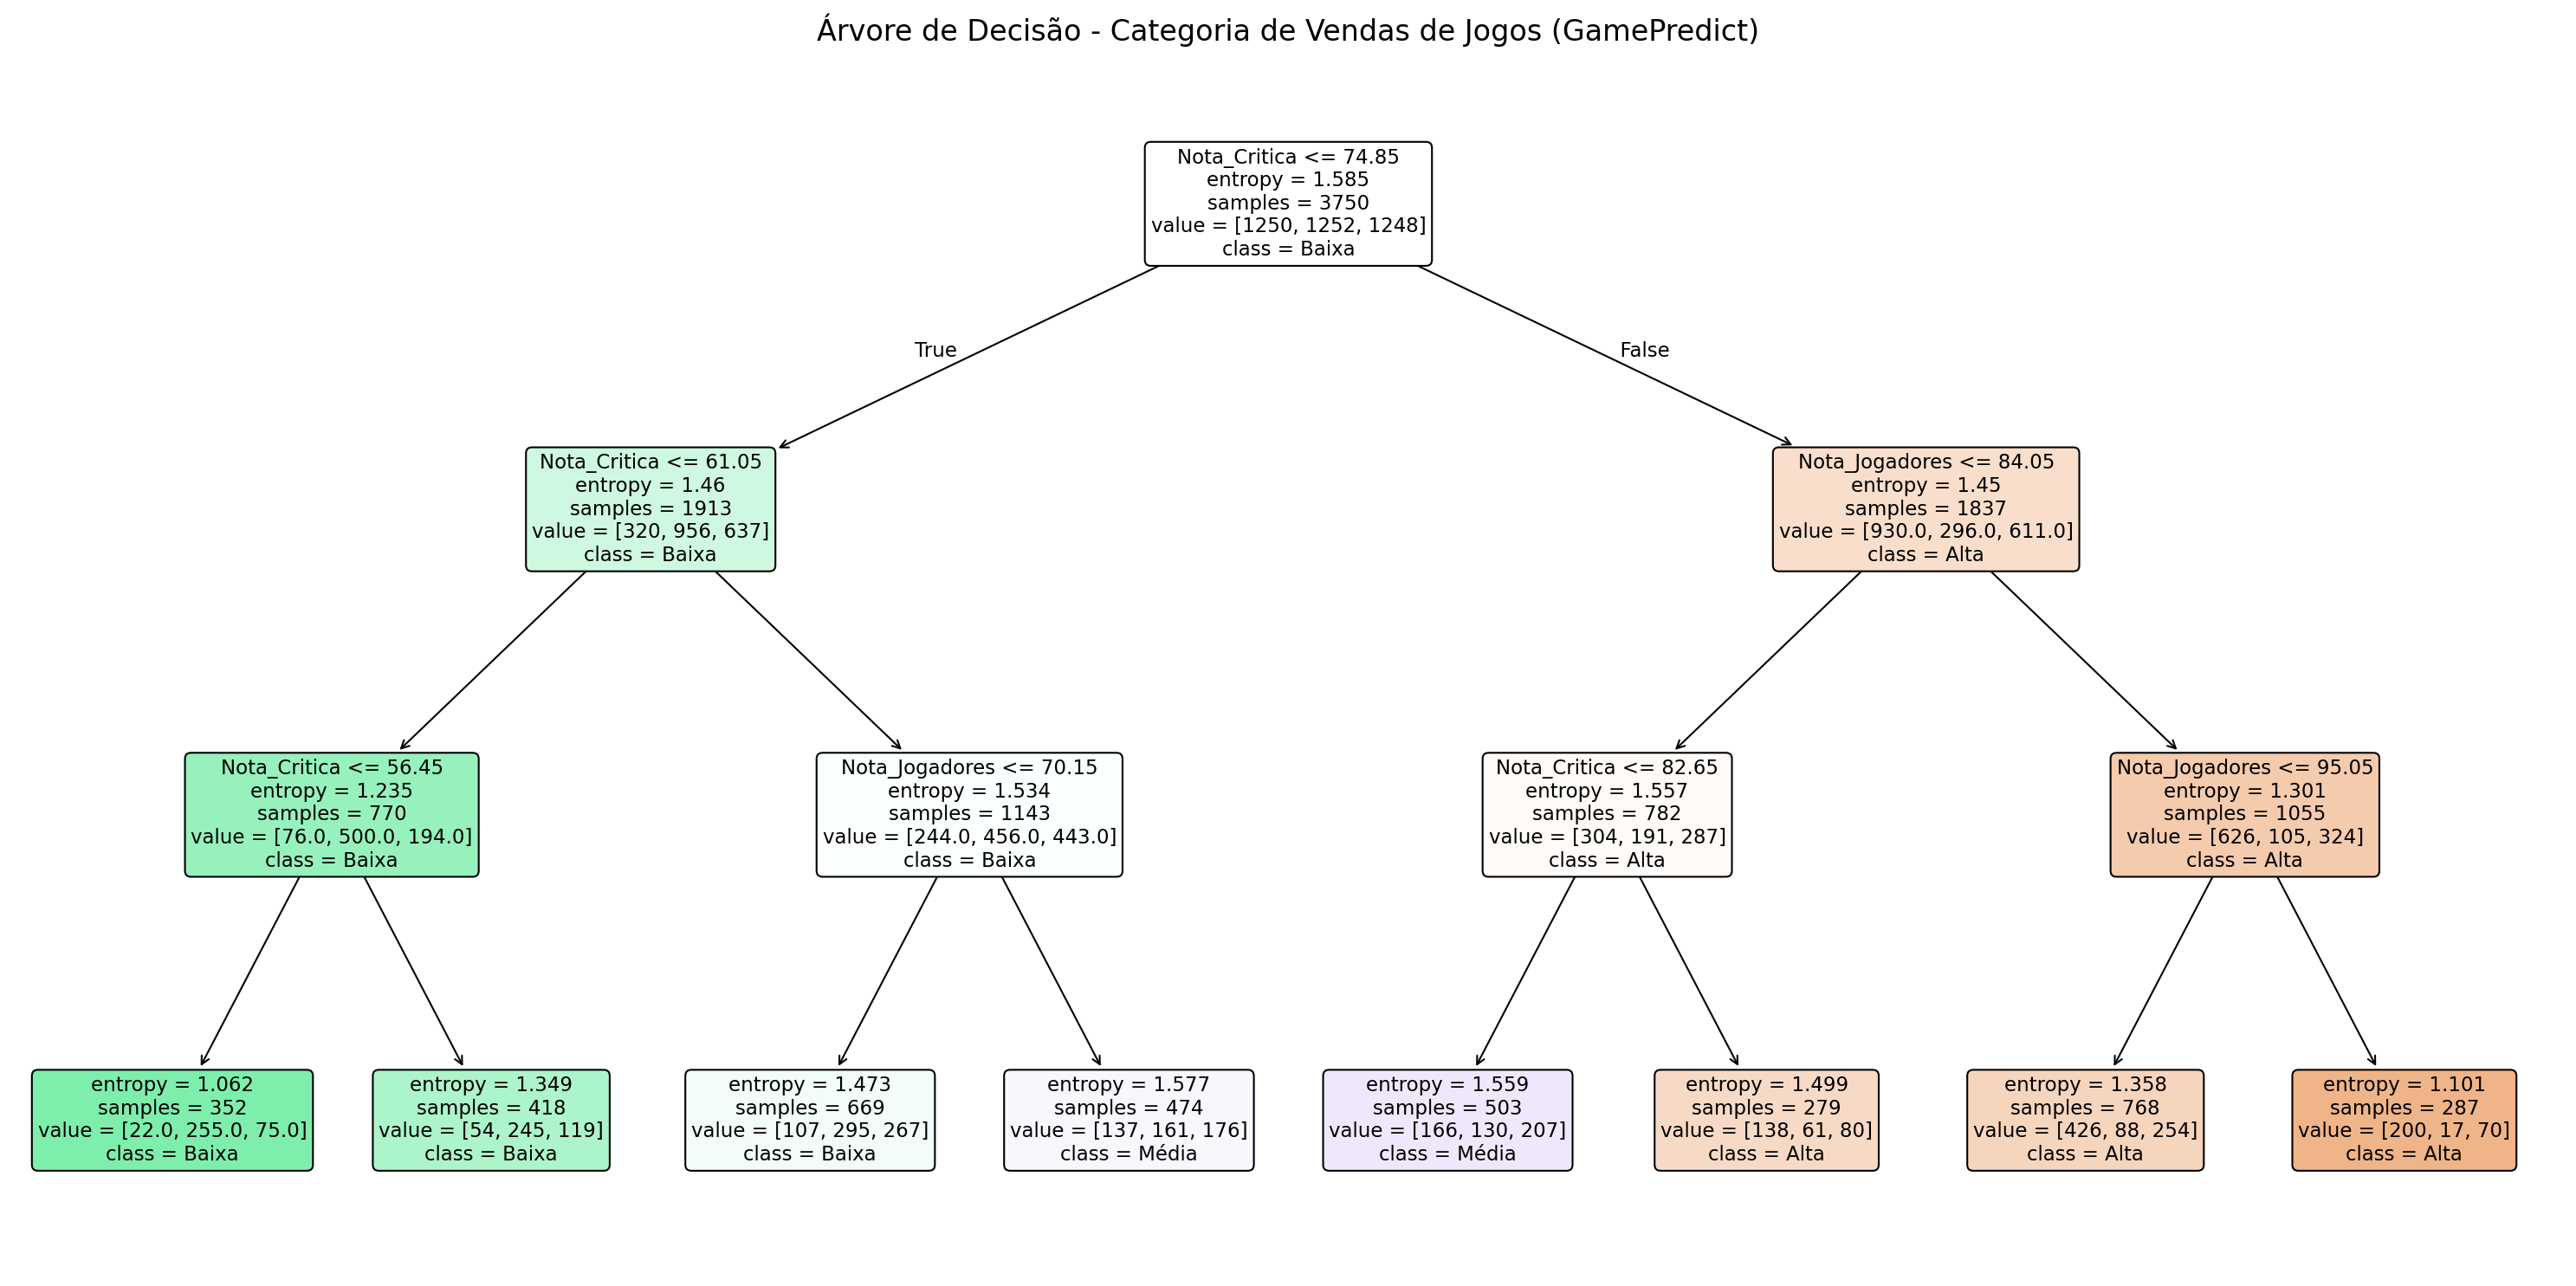

In [9]:
fig, ax = plt.subplots(figsize=(20, 10), dpi=150)
plot_tree(
    clf,
    feature_names=feature_cols,
    class_names=clf.classes_.astype(str),
    filled=True,
    rounded=True,
    fontsize=11,
    ax=ax
)
plt.title('Árvore de Decisão - Categoria de Vendas de Jogos (GamePredict)', fontsize=16)
plt.tight_layout()
plt.savefig('arvore_decisao_gamepredict.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Importância das variáveis

Mostra quais atributos mais contribuíram para as divisões da árvore — equivalente a identificar,
no exemplo do restaurante, se "tempo de espera" pesa mais que "está cheio" na decisão.

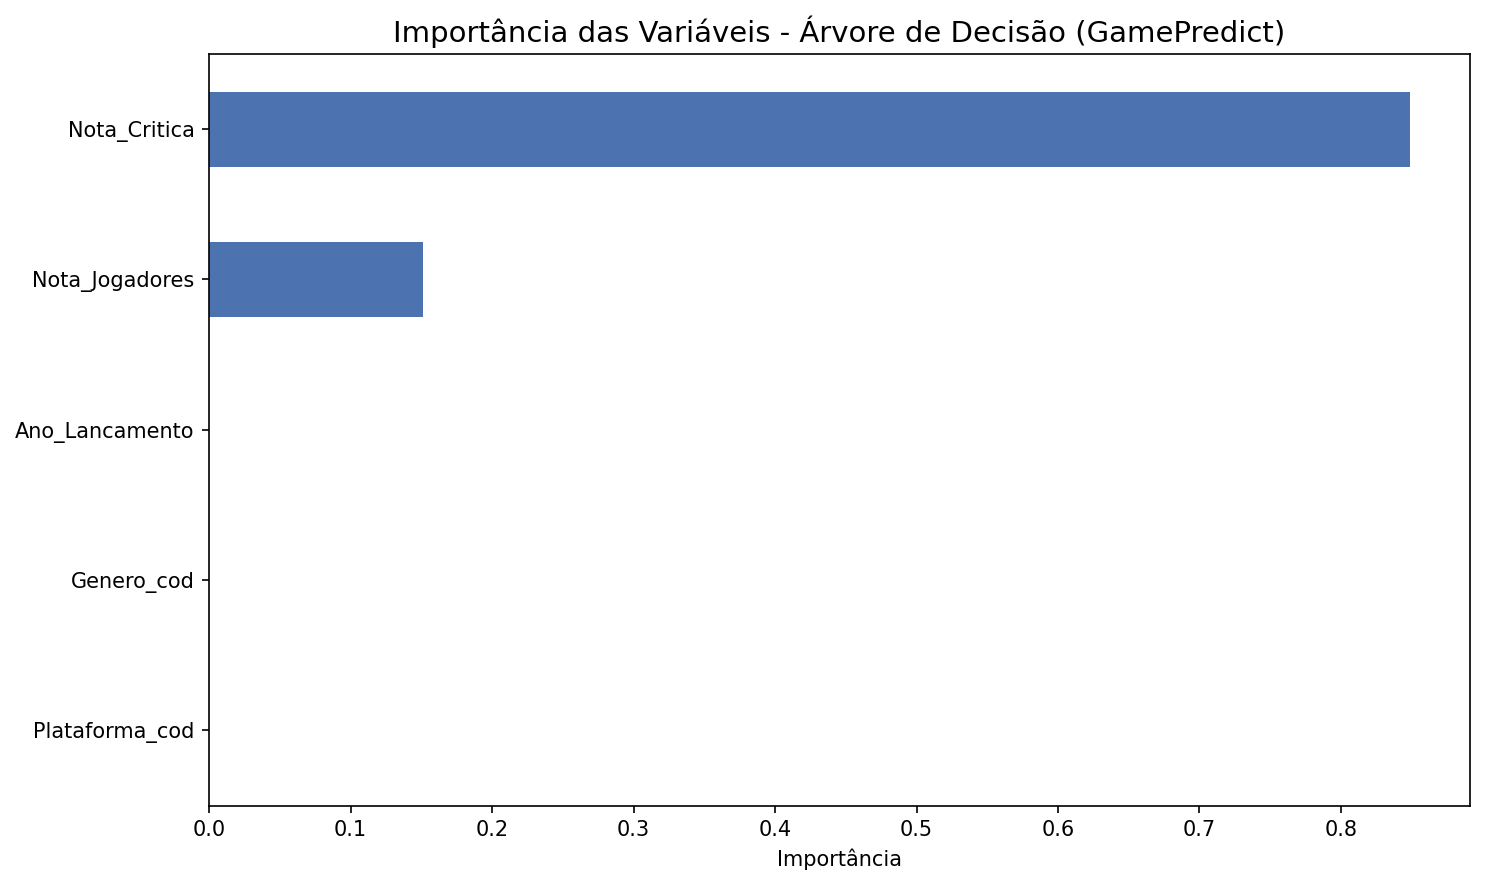

In [10]:
importancias = pd.Series(clf.feature_importances_, index=feature_cols).sort_values()

fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
importancias.plot(kind='barh', color='#4C72B0', ax=ax)
ax.set_title('Importância das Variáveis - Árvore de Decisão (GamePredict)', fontsize=14)
ax.set_xlabel('Importância')
plt.tight_layout()
plt.savefig('feature_importance_gamepredict.png', dpi=150, bbox_inches='tight')
plt.show()